# Titanic Data Analysis 

## Data Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\suvar\task2\titanic_dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Data Cleaning

In [4]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"], errors='ignore')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


## Data Analysis

In [6]:
survival_gender = df.groupby("Sex")["Survived"].mean()

print(f"Female: {survival_gender['female']*100:.1f}%")
print(f"Male: {survival_gender['male']*100:.1f}%")

print("\nFemales have higher survival rate.")

Female: 74.2%
Male: 18.9%

Females have higher survival rate.


In [7]:
survival_class = df.groupby("Pclass")["Survived"].mean()

print(f"Class 1 has {survival_class[1]*100:.1f}% survival rate")
print(f"Class 2 has {survival_class[2]*100:.1f}% survival rate")
print(f"Class 3 has {survival_class[3]*100:.1f}% survival rate")

print("\nYes, passenger class affected survival chances. Class 1 had the highest survival rate, while Class 3 had the lowest.")

Class 1 has 63.0% survival rate
Class 2 has 47.3% survival rate
Class 3 has 24.2% survival rate

Yes, passenger class affected survival chances. Class 1 had the highest survival rate, while Class 3 had the lowest.


In [8]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 19, 35, 60, 100],
                       labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

survival_age = df.groupby("AgeGroup", observed=True)["Survived"].mean()

for group, rate in survival_age.items():
    print(f"{group} - {rate*100:.1f}% survival rate")


Child - 58.0% survival rate
Teen - 41.1% survival rate
Young Adult - 35.3% survival rate
Adult - 40.0% survival rate
Senior - 22.7% survival rate


## Visualization

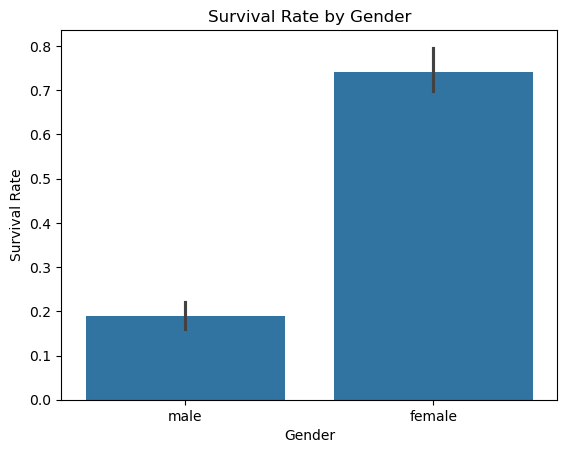

In [9]:
sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

             Females have higher survival rate than males.

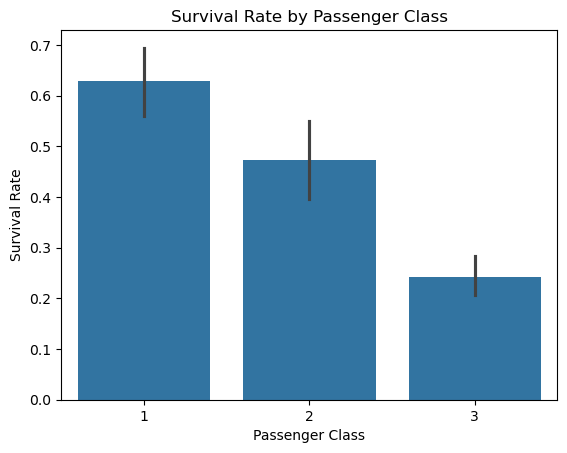

In [10]:
sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

            Class 1 has highest survival rate, Class 3 has lowest.

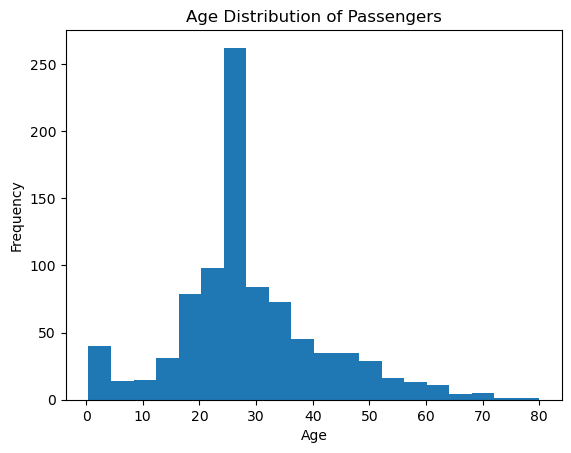

In [11]:
df["Age"].plot(kind="hist", bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.show()

                      Most passengers are between 20–40 years.

## Overall Conclusion

- Survival was influenced by gender, passenger class, and age  
- Females had higher survival chances than males  
- Higher-class passengers had better survival chances  
- Younger passengers showed slightly higher survival rates  